# PSUPR Clustering Submission Workshop

 - Objective: Understanding and Profiling Staff Attrition using cluster techniques

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42


# 1. Import Data

In [11]:
# https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
df.head()

# Attrition（是否离职）是标签，不参与聚类。


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 2. Variance Threshold

 - There are a few columns with low or zero variance.
 - You should remove them.
 - Note: You need to identify categorcial and numerical features to check for variance

VarianceThreshold 只能处理数值矩阵，类别列必须先挑出来单独判断。

In [12]:
from sklearn.feature_selection import VarianceThreshold

TARGET = "Attrition"

num_cols = df.select_dtypes(exclude="object").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Numerical columns   : %d" % len(num_cols))
print("Categorical columns : %d -> %s" % (len(cat_cols), cat_cols))

# EmployeeNumber 属于流水号
num_feat = [c for c in num_cols if c != "EmployeeNumber"]

vt = VarianceThreshold(threshold=0.0).fit(df[num_feat])
support = vt.get_support()
num_keep = [c for c, k in zip(num_feat, support) if k]
num_drop = [c for c, k in zip(num_feat, support) if not k]

print("\nNumerical columns removed (zero variance):", num_drop)
print("Values in those columns:", {c: df[c].unique().tolist() for c in num_drop})
print("EmployeeNumber removed by hand (variance %.1f)" % df["EmployeeNumber"].var())

cat_feat = [c for c in cat_cols if c != TARGET and df[c].nunique() > 1]
cat_drop = [c for c in cat_cols if c != TARGET and c not in cat_feat]
print("\nCategorical columns removed (single level):", cat_drop)

print("Kept: %d numerical + %d categorical" % (len(num_keep), len(cat_feat)))

# 最终：26 数值列 - EmployeeNumber - 2 个常量 = 23 个；
#       9 类别列 - Attrition - Over18 = 7 个。


Numerical columns   : 26
Categorical columns : 9 -> ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical columns removed (zero variance): ['EmployeeCount', 'StandardHours']
Values in those columns: {'EmployeeCount': [1], 'StandardHours': [80]}
EmployeeNumber removed by hand (variance 362433.3)

Categorical columns removed (single level): ['Over18']
Kept: 23 numerical + 7 categorical


# 3. Encode Categorical Variables

In [13]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

le = LabelEncoder()
y_attrition = le.fit_transform(df[TARGET])
print("Classes:", list(le.classes_), "->", np.bincount(y_attrition))
print("Overall attrition rate: %.2f%%" % (100 * y_attrition.mean()))

ohe = OneHotEncoder(drop="first", sparse_output=False)
X_cat = pd.DataFrame(ohe.fit_transform(df[cat_feat]),
                     columns=ohe.get_feature_names_out(cat_feat))

X = pd.concat([df[num_keep].reset_index(drop=True), X_cat], axis=1)
print("\nFinal feature matrix:", X.shape, "(%d numerical + %d dummies)"
      % (len(num_keep), X_cat.shape[1]))


# LabelEncoder 只用来编码二分标签 Attrition（No=0, Yes=1）；
# 其余类别列一律用 OneHotEncoder，避免引入不存在的顺序。


Classes: ['No', 'Yes'] -> [1233  237]
Overall attrition rate: 16.12%

Final feature matrix: (1470, 44) (23 numerical + 21 dummies)


# 4. Kmeans clustering
 - Use the scree plot to find the "optimal" number of clusters

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)


def find_elbow_point(values):
    values = np.asarray(values, dtype=float)
    coords = np.vstack((range(len(values)), values)).T
    first, last = coords[0], coords[-1]
    direction = (last - first) / np.linalg.norm(last - first)
    offset = coords - first
    projection = np.outer(np.dot(offset, direction), direction)
    return int(np.argmax(np.linalg.norm(offset - projection, axis=1)))

results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
    labels = km.fit_predict(X_std)
    results.append({"k": k,
                    "WCSS": km.inertia_,
                    "Silhouette": silhouette_score(X_std, labels),
                    "Davies-Bouldin": davies_bouldin_score(X_std, labels),
                    "Calinski-Harabasz": calinski_harabasz_score(X_std, labels)})

metrics_k = pd.DataFrame(results).set_index("k")
display(np.round(metrics_k, 4))

ks = metrics_k.index.values
print("Elbow on WCSS                 -> k =", ks[find_elbow_point(metrics_k["WCSS"].values)])
print("Elbow on Davies-Bouldin       -> k =", ks[find_elbow_point(metrics_k["Davies-Bouldin"].values)])
print("Best Silhouette               -> k =", int(metrics_k["Silhouette"].idxmax()))
print("Best Calinski-Harabasz        -> k =", int(metrics_k["Calinski-Harabasz"].idxmax()))
print("Best Davies-Bouldin (lowest)  -> k =", int(metrics_k["Davies-Bouldin"].idxmin()))


,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,59452.1784,0.1162,2.9357,129.0860
3,55078.1393,0.0967,2.7311,127.8722
4,53079.4676,0.1046,2.4091,106.7982
5,51360.3580,0.0942,2.8817,94.9822
6,49683.0683,0.1061,2.6684,88.3823
7,47928.0761,0.1006,2.5664,85.2251
8,46915.8968,0.1009,2.4870,79.0811
9,45435.2410,0.1007,2.6042,77.3535
10,44595.8592,0.0883,2.6614,73.0582


Elbow on WCSS                 -> k = 4
Elbow on Davies-Bouldin       -> k = 4
Best Silhouette               -> k = 2
Best Calinski-Harabasz        -> k = 2
Best Davies-Bouldin (lowest)  -> k = 4


- WCSS（簇内平方和）：越小簇越紧凑，但它随 k 单调下降。
- Silhouette（轮廓系数）：(b-a)/max(a,b)，兼顾簇内紧密度和簇间分离度，
    取值 [-1, 1]，越大越好。是四个指标里最综合的一个。
- Davies-Bouldin：簇内散度 / 簇间距离，越小越好。
- Calinski-Harabasz：簇间方差 / 簇内方差，越大越好。

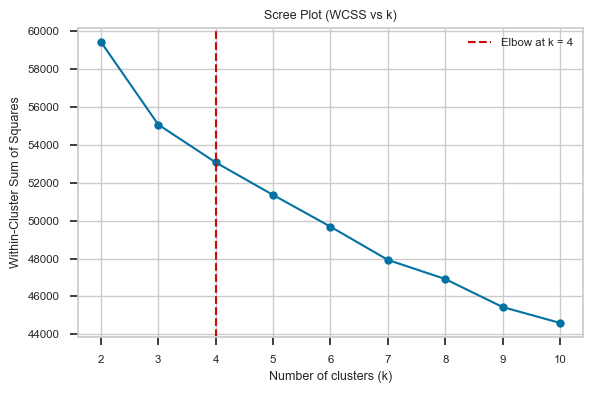

n_clusters = 2  Average silhouette_score = 0.1162
n_clusters = 3  Average silhouette_score = 0.0967
n_clusters = 4  Average silhouette_score = 0.1046
n_clusters = 5  Average silhouette_score = 0.0942
n_clusters = 6  Average silhouette_score = 0.1061
n_clusters = 7  Average silhouette_score = 0.1006


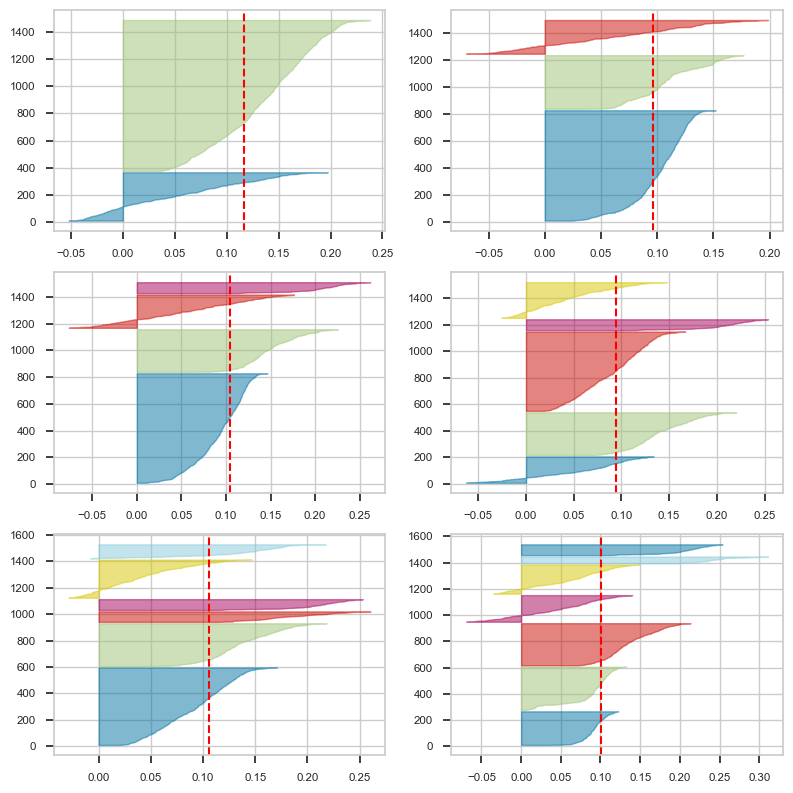

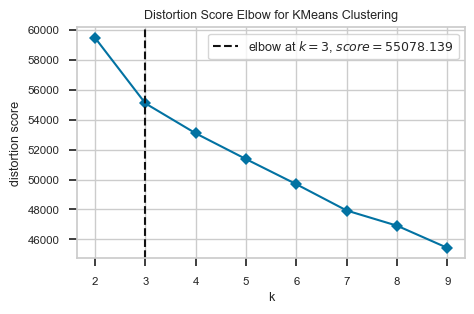

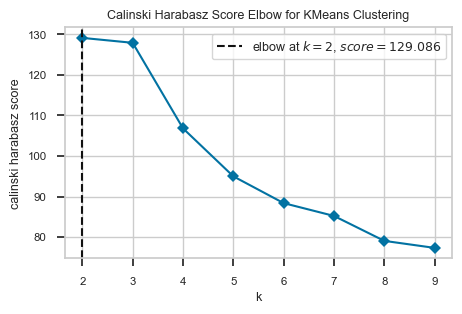

In [15]:
from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer

sns.set_context("notebook", font_scale=0.75)

elbow_k = ks[find_elbow_point(metrics_k["WCSS"].values)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, metrics_k["WCSS"], marker="o")
ax.axvline(x=elbow_k, color="r", linestyle="--", label="Elbow at k = %d" % elbow_k)
ax.set_title("Scree Plot (WCSS vs k)")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-Cluster Sum of Squares")
ax.legend()
plt.tight_layout()
plt.show()

#   每个簇是一把横条，条的高度 = 该样本的轮廓系数，红虚线 = 平均分。
fig, ax = plt.subplots(3, 2, figsize=(8, 8))
for i in [2, 3, 4, 5, 6, 7]:
    clusterer = KMeans(n_clusters=i, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
    q, mod = divmod(i, 2)
    visualizer = SilhouetteVisualizer(clusterer, colors="yellowbrick",
                                      ax=ax[q - 1][mod], force_model=True)
    visualizer.fit(X_std)
    print("n_clusters =", i, " Average silhouette_score = %.4f" % visualizer.silhouette_score_)
plt.tight_layout()
plt.show()

for metric in ["distortion", "calinski_harabasz"]:
    clusterer = KMeans(n_clusters=2, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
    visualizer = KElbowVisualizer(clusterer, k=(2, 10), metric=metric,
                                  size=(500, 300), timings=False, force_model=True)
    visualizer.fit(X_std)
    visualizer.poof()



In [16]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
labels_kmeans = kmeans.fit_predict(X_std)

print("KMeans with k = %d" % OPTIMAL_K)
print("Silhouette score   : %.4f" % silhouette_score(X_std, labels_kmeans))
print("Davies-Bouldin     : %.4f" % davies_bouldin_score(X_std, labels_kmeans))
print("Calinski-Harabasz  : %.1f" % calinski_harabasz_score(X_std, labels_kmeans))

sil = silhouette_samples(X_std, labels_kmeans)
for c in range(OPTIMAL_K):
    print("  Cluster %d: n = %4d | mean silhouette = %.3f | min = %.3f"
          % (c, (labels_kmeans == c).sum(), sil[labels_kmeans == c].mean(), sil[labels_kmeans == c].min()))

from sklearn.metrics import adjusted_rand_score

X_num_std = StandardScaler().fit_transform(df[num_keep])
lab_num_only = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10,
                      max_iter=300, random_state=SEED).fit_predict(X_num_std)
print("\nSilhouette using numerical columns only : %.4f" % silhouette_score(X_num_std, lab_num_only))
print("ARI between the two solutions           : %.4f" % adjusted_rand_score(labels_kmeans, lab_num_only))


KMeans with k = 4
Silhouette score   : 0.1046
Davies-Bouldin     : 2.4091
Calinski-Harabasz  : 106.8
  Cluster 0: n =  819 | mean silhouette = 0.092 | min = 0.008
  Cluster 1: n =  319 | mean silhouette = 0.150 | min = 0.049
  Cluster 2: n =  249 | mean silhouette = 0.054 | min = -0.076
  Cluster 3: n =   83 | mean silhouette = 0.205 | min = 0.099

Silhouette using numerical columns only : 0.0962
ARI between the two solutions           : 0.1931


## 4.a Analysis of Kmeans solution

### 1. Is this a good technical solution?

No. Silhouette at k = 4 is only 0.10 and it stays flat from k = 2 to 10 (0.09-0.12), so no k really stands out.

The clusters are also just the job families again: cluster 1 is 99.7% Sales Executive, cluster 3 is 100% Sales Representative, cluster 2 is 40.2% Manager. Clustering on the numerical columns alone gives silhouette 0.10 and ARI 0.19, so the one-hot dummies are what drives the split.

The indices disagree too - silhouette and Calinski-Harabasz want k = 2, the WCSS elbow and Davies-Bouldin want k = 4. I kept k = 4 because k = 2 only separates senior staff from everyone else.


In [17]:
df['Cluster'] = labels_kmeans

profile = df.groupby('Cluster').agg('mean', numeric_only=True)
profile['Count'] = df.groupby('Cluster')['Cluster'].count()
profile['Attrition_Rate'] = df.groupby('Cluster')[TARGET].apply(lambda s: (s == 'Yes').mean())
profile['Attrition_Count'] = df.groupby('Cluster')[TARGET].apply(lambda s: (s == 'Yes').sum())

interesting = ['Age', 'JobLevel', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
               'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
               'StockOptionLevel', 'JobSatisfaction', 'Count', 'Attrition_Rate', 'Attrition_Count']
display(np.round(profile[interesting].T, 2))

def eta_squared(frame, labels):
    grand = frame.mean(axis=0)
    ss_total = ((frame - grand) ** 2).sum(axis=0)
    ss_between = np.zeros(frame.shape[1])
    for c in np.unique(labels):
        mask = labels == c
        ss_between += mask.sum() * (frame[mask].mean(axis=0) - grand) ** 2
    return pd.Series(ss_between / ss_total, index=frame.columns).sort_values(ascending=False)

eta_kmeans = eta_squared(df[num_keep], labels_kmeans)
print("Top discriminating numerical features (eta-squared):")
print(eta_kmeans.head(8).round(4).to_string())


Cluster,0,1,2,3
Age,34.98,36.55,46.00,30.36
JobLevel,1.51,2.29,3.93,1.08
MonthlyIncome,4174.20,6793.55,15082.49,2626.00
TotalWorkingYears,8.45,10.67,23.56,4.67
YearsAtCompany,5.30,7.17,13.79,2.92
YearsInCurrentRole,3.44,4.73,6.93,2.01
YearsSinceLastPromotion,1.47,2.33,4.73,1.06
YearsWithCurrManager,3.47,4.53,6.57,1.66
StockOptionLevel,0.80,0.82,0.80,0.63
JobSatisfaction,2.73,2.77,2.67,2.73


Top discriminating numerical features (eta-squared):
MonthlyIncome              0.7385
JobLevel                   0.6773
TotalWorkingYears          0.5377
YearsAtCompany             0.2763
Age                        0.2223
YearsInCurrentRole         0.1464
YearsSinceLastPromotion    0.1404
YearsWithCurrManager       0.1285


In [18]:
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus']:
    print("-- %s (%% within cluster) --" % col)
    display(pd.crosstab(df['Cluster'], df[col], normalize='index').mul(100).round(1))


-- Department (% within cluster) --


Department,Human Resources,Research & Development,Sales
Cluster,,,
0,6.1,93.9,0.0
1,0.0,0.0,100.0
2,5.2,77.1,17.7
3,0.0,0.0,100.0


-- JobRole (% within cluster) --


JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
Cluster,,,,,,,,,
0,12.3,6.1,31.4,0.1,14.5,0.0,35.5,0.0,0.0
1,0.0,0.0,0.0,0.3,0.0,0.0,0.0,99.7,0.0
2,12.0,0.8,0.8,40.2,10.4,32.1,0.4,3.2,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


-- OverTime (% within cluster) --


OverTime,No,Yes
Cluster,,
0,72.5,27.5
1,71.5,28.5
2,69.5,30.5
3,71.1,28.9


-- MaritalStatus (% within cluster) --


MaritalStatus,Divorced,Married,Single
Cluster,,,
0,23.0,44.3,32.7
1,21.3,46.4,32.3
2,24.1,51.4,24.5
3,13.3,41.0,45.8


### 2. Is this a good business solution in understanding employee attrition?

Partly. It finds the senior group and the high-risk group, but both were already visible in JobRole.

| Cluster | Size | Who they are | Attrition |
|---|---|---|---|
| 0 | 819 | R&D - Lab Technicians (31.4%), Research Scientists (35.5%) | 16.5% |
| 1 | 319 | Sales Executives (99.7%) | 17.2% |
| 2 | 249 | Managers (40.2%), Research Directors (32.1%) | 5.6% |
| 3 | 83 | Sales Representatives (100%) | 39.8% |

Baseline is 16.1%, so clusters 2 and 3 are the useful ones. But cluster 3 is exactly "Sales Representative" - a plain `groupby('JobRole')` returns the same 39.8%. Overtime, the strongest driver in the data (30.5% vs 10.4%), is not captured either: every cluster has 27%-31% overtime. Clusters 0 and 1 also have almost the same attrition (16.5% vs 17.2%), and at 83 people cluster 3 is too small to target.


### 3. Generate boxplots for those features that best discriminate each cluster from one another and explain why it is the case.

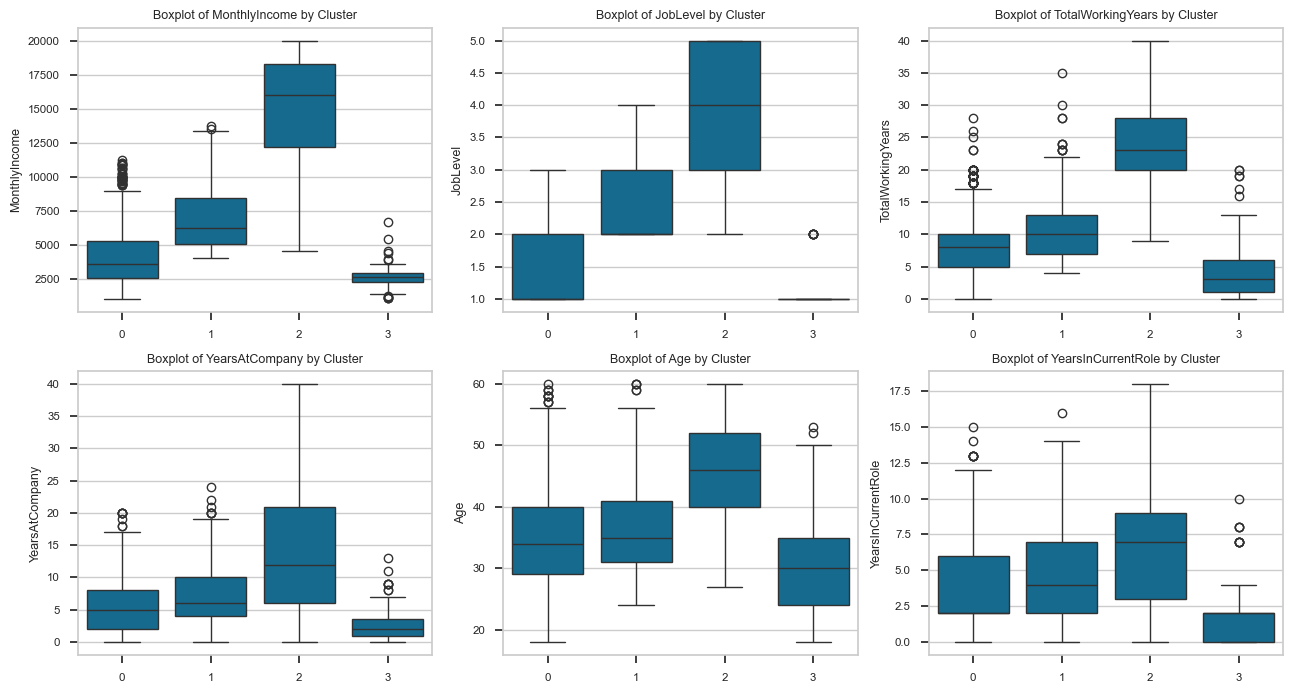

In [19]:
top_feats = eta_kmeans.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes_flat = axes.flatten()

for i, feature in enumerate(top_feats):
    sns.boxplot(x='Cluster', y=feature, data=df, ax=axes_flat[i])
    axes_flat[i].set_title('Boxplot of %s by Cluster' % feature)
    axes_flat[i].set_xlabel('')

plt.tight_layout()
plt.show()


In [20]:
summary = pd.concat([profile[top_feats].T.round(1),
                     df.groupby('Cluster')[top_feats].std().T.round(1)],
                    keys=['Mean', 'Std'])
display(summary)

rate = pd.Series(y_attrition).groupby(labels_kmeans).mean()
print("Attrition rate by cluster:")
print((100 * rate).round(1).to_string())


Cluster                       0       1        2       3
Mean MonthlyIncome       4174.2  6793.5  15082.5  2626.0
     JobLevel               1.5     2.3      3.9     1.1
     TotalWorkingYears      8.5    10.7     23.6     4.7
     YearsAtCompany         5.3     7.2     13.8     2.9
     Age                   35.0    36.5     46.0    30.4
     YearsInCurrentRole     3.4     4.7      6.9     2.0
Std  MonthlyIncome       2080.8  2199.3   3689.5   854.5
     JobLevel               0.6     0.5      0.8     0.3
     TotalWorkingYears      4.8     5.1      6.9     5.0
     YearsAtCompany         3.8     4.6      9.2     2.7
     Age                    8.3     7.9      7.4     8.5
     YearsInCurrentRole     3.1     3.3      4.4     2.3

Attrition rate by cluster:
0    16.5
1    17.2
2     5.6
3    39.8


**Why do these features discriminate?**

Because they all measure seniority. The six features with the highest eta-squared - MonthlyIncome (0.74), JobLevel (0.68), TotalWorkingYears (0.54), YearsAtCompany (0.28), Age (0.22) and YearsInCurrentRole (0.15) - are highly correlated, and PC1 confirms it by loading 0.88 on JobLevel, 0.87 on MonthlyIncome and 0.86 on TotalWorkingYears. One axis counted six times, not six findings.

So KMeans recovered the org chart rather than the attrition drivers. Cluster 2 sits far above the rest on every seniority measure - \$15,082/month against \$4,174 and \$2,626, 23.6 years of experience against 8.5 and 4.7. Clusters 0 and 3 are the two closest groups on pay (\$4,174 against \$2,626 a month, JobLevel 1.5 against 1.1), yet they have the widest attrition gap of all, 16.5% against 39.8%.


### 4. Provide the profile of each cluster

| Cluster | n | Age | JobLevel | MonthlyIncome | TotalWorkingYears | YearsAtCompany | Attrition |
|---|---|---|---|---|---|---|---|
| 0 | 819 | 35.0 | 1.5 | \$4,174 | 8.5 | 5.3 | 16.5% |
| 1 | 319 | 36.5 | 2.3 | \$6,794 | 10.7 | 7.2 | 17.2% |
| 2 | 249 | 46.0 | 3.9 | \$15,082 | 23.6 | 13.8 | 5.6% |
| 3 | 83 | 30.4 | 1.1 | \$2,626 | 4.7 | 2.9 | 39.8% |

- Cluster 0 (819, 55.7%) - R&D technical staff, 93.9% in R&D, mostly Lab Technicians and Research Scientists. Attrition 16.5%, same as the average employee.
- Cluster 1 (319, 21.7%) - Sales Executives, 100% in Sales. Attrition 17.2%, only 0.7 points above cluster 0, so the split is not useful.
- Cluster 2 (249, 16.9%) - senior management, 77.1% R&D, 40.2% Managers and 32.1% Research Directors. Attrition 5.6%, one third of the baseline.
- Cluster 3 (83, 5.6%) - Sales Representatives, 100% in Sales, 45.8% single against 24.5% in cluster 2. Attrition 39.8%, the high-risk group.


# 5. Dimension Reduction using PCA
 - reduce the dimensions of the dataset
 - Find an appropriate number of PCs to retain

PCs with eigenvalue > 1 (Kaiser criterion) : 19
PCs needed for 80% cumulative variance       : 23
PCs needed for 90% cumulative variance       : 28

Automated scree elbow -> retain 8 PCs (43.9% cumulative variance)


,Eigenvalue,Explained variance,Cumulative
PC1,5.3412,0.1213,0.1213
PC2,3.4555,0.0785,0.1998
PC3,2.0720,0.0471,0.2469
PC4,1.9898,0.0452,0.2920
PC5,1.7869,0.0406,0.3326
PC6,1.7204,0.0391,0.3717
PC7,1.6083,0.0365,0.4082
PC8,1.3457,0.0306,0.4388
PC9,1.3015,0.0296,0.4683
PC10,1.2405,0.0282,0.4965


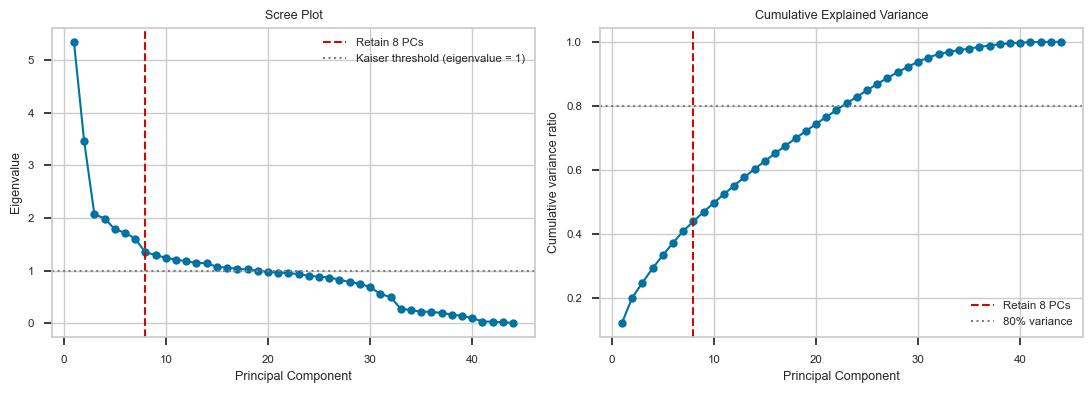

In [21]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=SEED).fit(X_std)

eigenvalues = pca_full.explained_variance_
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_table = pd.DataFrame({"Eigenvalue": eigenvalues,
                          "Explained variance": explained,
                          "Cumulative": cumulative},
                         index=["PC%d" % (i + 1) for i in range(len(eigenvalues))])

print("PCs with eigenvalue > 1 (Kaiser criterion) :", int((eigenvalues > 1).sum()))
print("PCs needed for 80% cumulative variance       :", int(np.argmax(cumulative >= 0.80) + 1))
print("PCs needed for 90% cumulative variance       :", int(np.argmax(cumulative >= 0.90) + 1))

N_PC = find_elbow_point(eigenvalues) + 1
print("\nAutomated scree elbow -> retain %d PCs (%.1f%% cumulative variance)"
      % (N_PC, 100 * cumulative[N_PC - 1]))

display(np.round(pca_table.head(15), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
axes[0].axvline(x=N_PC, color='r', linestyle='--', label='Retain %d PCs' % N_PC)
axes[0].axhline(y=1, color='grey', linestyle=':', label='Kaiser threshold (eigenvalue = 1)')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o')
axes[1].axvline(x=N_PC, color='r', linestyle='--', label='Retain %d PCs' % N_PC)
axes[1].axhline(y=0.80, color='grey', linestyle=':', label='80% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative variance ratio')
axes[1].legend()
plt.tight_layout()
plt.show()


## 4.b Analysis of Kmeans solution

**Generate the loadings matrix.** Correlation loadings (eigenvector x sqrt(eigenvalue)): the correlation between each original feature and each component. Values above about 0.5 in absolute value define the component.


In [22]:
loadings = pca_full.components_[:N_PC].T * np.sqrt(eigenvalues[:N_PC])
loadings_df = pd.DataFrame(loadings, index=X.columns,
                           columns=["PC%d" % (i + 1) for i in range(N_PC)])

print("Loadings matrix:", loadings_df.shape)
display(np.round(loadings_df, 3))


Loadings matrix: (44, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Age,0.596,-0.128,-0.159,-0.291,0.127,0.141,0.041,0.152
DailyRate,-0.007,-0.032,-0.138,0.005,0.032,0.037,-0.021,0.057
DistanceFromHome,0.007,0.024,-0.053,0.104,0.057,0.004,-0.022,0.115
Education,0.164,0.010,-0.048,-0.130,0.014,0.065,0.144,0.330
EnvironmentSatisfaction,-0.001,-0.027,0.029,-0.023,-0.069,-0.023,-0.019,0.048
HourlyRate,-0.019,-0.019,-0.123,-0.008,-0.013,0.008,0.104,0.086
JobInvolvement,-0.000,-0.039,-0.094,-0.007,-0.058,0.019,0.022,0.230
JobLevel,0.880,-0.008,-0.038,-0.270,0.098,0.098,-0.027,-0.100
JobSatisfaction,-0.019,0.009,0.055,0.036,0.042,0.069,0.090,-0.024
MonthlyIncome,0.866,-0.063,-0.051,-0.307,0.108,0.094,-0.037,-0.115



PC1  |  eigenvalue = 5.341  |  explains 12.1%  |  cumulative 12.1%
JobLevel                0.880
MonthlyIncome           0.866
TotalWorkingYears       0.864
YearsAtCompany          0.791
YearsInCurrentRole      0.667
YearsWithCurrManager    0.652

PC2  |  eigenvalue = 3.456  |  explains 7.8%  |  cumulative 20.0%
Department_Sales                     0.945
Department_Research & Development   -0.930
JobRole_Sales Executive              0.803
EducationField_Marketing             0.653
JobRole_Sales Representative         0.368
JobRole_Research Scientist          -0.319

PC3  |  eigenvalue = 2.072  |  explains 4.7%  |  cumulative 24.7%
MaritalStatus_Single                0.819
MaritalStatus_Married              -0.655
StockOptionLevel                   -0.653
BusinessTravel_Travel_Rarely       -0.315
BusinessTravel_Travel_Frequently    0.314
YearsWithCurrManager                0.226

PC4  |  eigenvalue = 1.990  |  explains 4.5%  |  cumulative 29.2%
YearsInCurrentRole         0.459
NumCompa

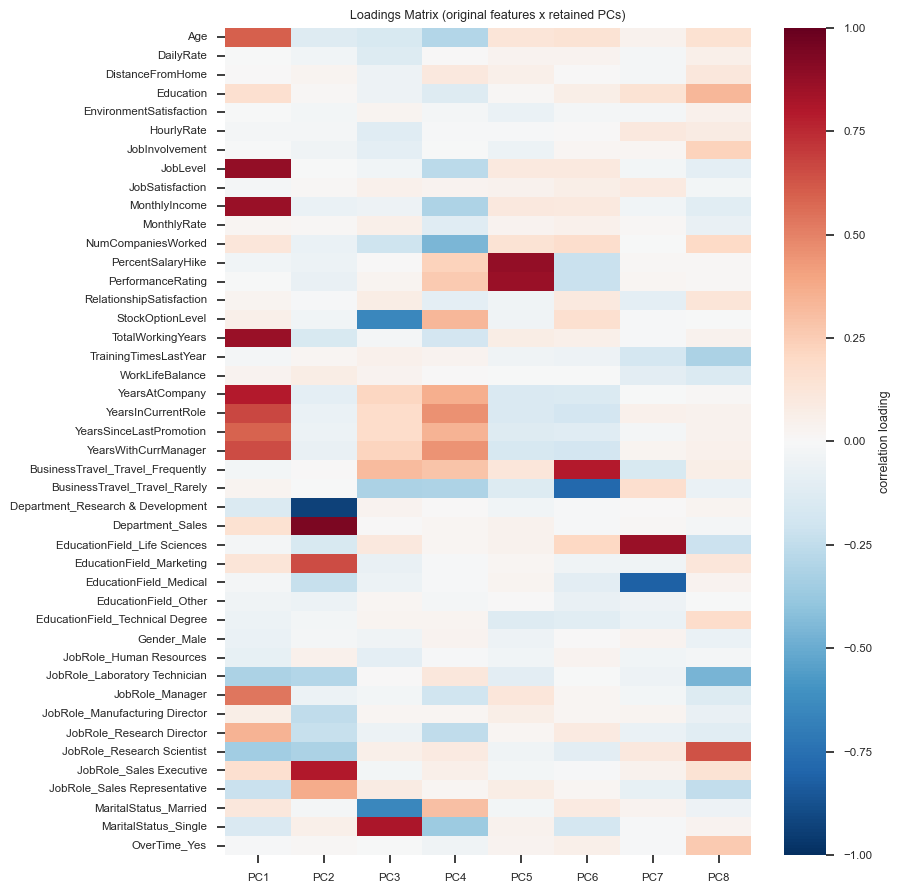

In [23]:
for pc in loadings_df.columns:
    order = loadings_df[pc].abs().sort_values(ascending=False).index
    top = loadings_df[pc].reindex(order).head(6)
    n = int(pc[2:])
    print("\n%s  |  eigenvalue = %.3f  |  explains %.1f%%  |  cumulative %.1f%%"
          % (pc, eigenvalues[n - 1], 100 * explained[n - 1], 100 * cumulative[n - 1]))
    print(top.round(3).to_string())

plt.figure(figsize=(9, 9))
sns.heatmap(loadings_df, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'correlation loading'})
plt.title('Loadings Matrix (original features x retained PCs)')
plt.tight_layout()
plt.show()


**Are you able to interpret each PC with respect to the original features?**

Yes, all eight have a clear reading.

| PC | Var | Strongest loadings | Interpretation |
|---|---|---|---|
| PC1 | 12.1% | JobLevel +0.88, MonthlyIncome +0.87, TotalWorkingYears +0.86 | Career seniority and pay |
| PC2 | 7.8% | Department_Sales +0.94, Department_Research & Development -0.93 | Line of business |
| PC3 | 4.7% | MaritalStatus_Single +0.82, StockOptionLevel -0.65 | Life stage and stock options |
| PC4 | 4.5% | YearsInCurrentRole +0.46, NumCompaniesWorked -0.46 | Settled vs mobile |
| PC5 | 4.1% | PercentSalaryHike +0.88, PerformanceRating +0.86 | Reward momentum |
| PC6 | 3.9% | BusinessTravel_Travel_Frequently +0.80, BusinessTravel_Travel_Rarely -0.79 | Travel intensity |
| PC7 | 3.7% | EducationField_Life Sciences +0.86, EducationField_Medical -0.82 | Academic background |
| PC8 | 3.1% | JobRole_Research Scientist +0.64, JobRole_Laboratory Technician -0.46 | Technical role type |

**Describe your selected PCs from the domain perspective**

I keep 8 PCs, explaining 43.9% of the variance. That is low because the 44 HR variables are weakly correlated and no structure dominates - even PC1 only explains 12.1%. For HR they come down to three themes: career stage (PC1, PC4), job family (PC2, PC7, PC8) and life stage and rewards (PC3, PC5, PC6). PC5 is not a real finding - PercentSalaryHike is fully determined by PerformanceRating (rating 3 gives 11%-19%, rating 4 gives 20%-25%), so it is the same variable twice.


# 6. Clustering with PCs
 -  perform Kmeans clustering with the PCs
 -  In order to interpret the clusters, you need to revert back to the original features.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

Z = pca_full.transform(X_std)[:, :N_PC]

pc_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
    labels = km.fit_predict(Z)
    pc_results.append({"k": k,
                       "WCSS": km.inertia_,
                       "Silhouette": silhouette_score(Z, labels),
                       "Davies-Bouldin": davies_bouldin_score(Z, labels),
                       "Calinski-Harabasz": calinski_harabasz_score(Z, labels)})

pc_metrics = pd.DataFrame(pc_results).set_index("k")
display(np.round(pc_metrics, 4))

ks_pc = pc_metrics.index.values
print("Elbow on WCSS           -> k =", ks_pc[find_elbow_point(pc_metrics["WCSS"].values)])
print("Best Silhouette         -> k =", int(pc_metrics["Silhouette"].idxmax()))
print("Best Davies-Bouldin     -> k =", int(pc_metrics["Davies-Bouldin"].idxmin()))
print("Best Calinski-Harabasz  -> k =", int(pc_metrics["Calinski-Harabasz"].idxmax()))


,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,23178.6569,0.1984,1.9562,329.4829
3,19031.4652,0.2236,1.6066,360.3427
4,17537.4774,0.1771,1.8376,302.1441
5,16402.8324,0.1758,1.7285,267.4530
6,15520.8042,0.1695,1.7767,242.6067
7,14666.8495,0.1628,1.7682,227.9941
8,13842.0609,0.1602,1.7939,219.3713
9,13307.3199,0.1493,1.7897,206.8653
10,12605.4833,0.1636,1.7009,203.0173


Elbow on WCSS           -> k = 4
Best Silhouette         -> k = 3
Best Davies-Bouldin     -> k = 3
Best Calinski-Harabasz  -> k = 3


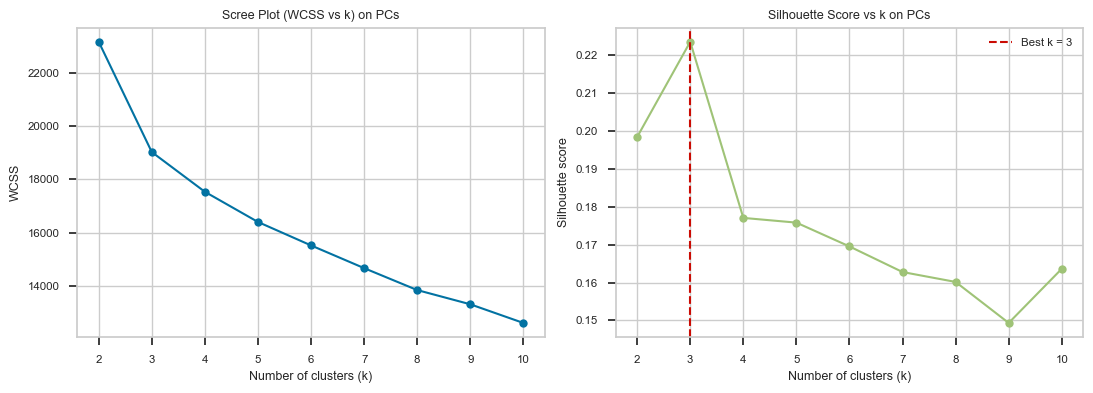

KMeans on 8 PCs with k = 3
Silhouette score  : 0.2236  (versus 0.1046 on the full 44 features)
Davies-Bouldin    : 1.6066
Calinski-Harabasz : 360.3
  Cluster 0: n =  795 | mean silhouette = 0.230 | min = 0.003
  Cluster 1: n =  398 | mean silhouette = 0.243 | min = 0.057
  Cluster 2: n =  277 | mean silhouette = 0.177 | min = -0.059

ARI against the full-feature KMeans solution: 0.8880


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks_pc, pc_metrics["WCSS"], marker='o')
axes[0].set_title('Scree Plot (WCSS vs k) on PCs')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('WCSS')

axes[1].plot(ks_pc, pc_metrics["Silhouette"], marker='o', color='g')
axes[1].axvline(x=int(pc_metrics["Silhouette"].idxmax()), color='r', linestyle='--',
                label='Best k = %d' % int(pc_metrics["Silhouette"].idxmax()))
axes[1].set_title('Silhouette Score vs k on PCs')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].legend()
plt.tight_layout()
plt.show()

# Silhouette, Davies-Bouldin and Calinski-Harabasz all agree on k = 3.
OPTIMAL_K_PC = 3

km_pc = KMeans(n_clusters=OPTIMAL_K_PC, init="k-means++", n_init=10, max_iter=300, random_state=SEED)
labels_pc = km_pc.fit_predict(Z)

print("KMeans on %d PCs with k = %d" % (N_PC, OPTIMAL_K_PC))
print("Silhouette score  : %.4f  (versus %.4f on the full 44 features)"
      % (silhouette_score(Z, labels_pc), silhouette_score(X_std, labels_kmeans)))
print("Davies-Bouldin    : %.4f" % davies_bouldin_score(Z, labels_pc))
print("Calinski-Harabasz : %.1f" % calinski_harabasz_score(Z, labels_pc))

sil_pc = silhouette_samples(Z, labels_pc)
for c in range(OPTIMAL_K_PC):
    print("  Cluster %d: n = %4d | mean silhouette = %.3f | min = %.3f"
          % (c, (labels_pc == c).sum(), sil_pc[labels_pc == c].mean(), sil_pc[labels_pc == c].min()))

print("\nARI against the full-feature KMeans solution: %.4f"
      % adjusted_rand_score(labels_pc, labels_kmeans))


In [26]:
print("%-6s %-10s %-34s %-22s" % ("n_PC", "cum.var", "attrition rate per cluster", "cluster sizes"))
for n in [5, 8, 10, 19]:
    Z_n = pca_full.transform(X_std)[:, :n]
    lab_n = KMeans(3, init="k-means++", n_init=10, max_iter=300, random_state=SEED).fit_predict(Z_n)
    rates = pd.Series(y_attrition).groupby(lab_n).mean().round(3).values
    sizes = pd.Series(lab_n).value_counts().sort_index().values
    print("%-6d %-10.3f %-34s %-22s" % (n, cumulative[n - 1], np.round(rates, 3), sizes))


n_PC   cum.var    attrition rate per cluster         cluster sizes         
5      0.333      [0.057 0.17  0.219]                [283 790 397]         
8      0.439      [0.169 0.219 0.058]                [795 398 277]         
10     0.497      [0.168 0.221 0.055]                [797 399 274]         
19     0.721      [0.165 0.055 0.221]                [816 255 399]         


## 6a Kmeans clustering with Principal Components Analysis

**Is this a good technical solution?**

Yes, better than the 44-feature version.

- All three indices agree on k = 3 (silhouette 0.2236, Davies-Bouldin 1.6066, Calinski-Harabasz 360.3); for 44 features they disagreed.
- Silhouette improves from 0.10 to 0.22, so the 36 dropped dimensions were mostly noise.
- Per-cluster silhouettes are 0.230 / 0.243 / 0.177, so no cluster is badly assigned.
- ARI against the full-feature solution is 0.89, so little was thrown away.

**Is this a good business solution in understanding employee attrition? Provide the profile of each cluster.**

Yes, it gives a usable risk gradient. The table is the profile of each cluster.

| Cluster | Size | Age | JobLevel | MonthlyIncome | Who they are | Attrition |
|---|---|---|---|---|---|---|
| 0 | 795 (54%) | 34.8 | 1.5 | \$4,087 | R&D technical - Lab Technicians (31.8%), Research Scientists (36.4%) | 16.9% |
| 1 | 398 (27%) | 35.1 | 2.0 | \$5,897 | Sales - Sales Executives (78.4%), Sales Representatives (20.9%) | 21.9% |
| 2 | 277 (19%) | 45.7 | 3.8 | \$14,305 | Senior leadership - Managers (35.4%), Research Directors (28.5%) | 5.8% |

Against the 16.1% baseline senior leadership is 0.4x, sales 1.4x and R&D technical is average, and the sizes are large enough to act on. Two problems remain: overtime is still not captured (27.4% / 28.6% / 30.3%), and cluster 2 is basically everyone above JobLevel 3.


In [27]:
df['Cluster_PC'] = labels_pc

profile_pc = df.groupby('Cluster_PC').agg('mean', numeric_only=True)
profile_pc['Count'] = df.groupby('Cluster_PC')['Cluster_PC'].count()
profile_pc['Attrition_Rate'] = df.groupby('Cluster_PC')[TARGET].apply(lambda s: (s == 'Yes').mean())
profile_pc['Attrition_Count'] = df.groupby('Cluster_PC')[TARGET].apply(lambda s: (s == 'Yes').sum())

display(np.round(profile_pc[interesting].T, 2))

eta_pc = eta_squared(df[num_keep], labels_pc)
print("Top discriminating numerical features (eta-squared):")
print(eta_pc.head(8).round(4).to_string())

print()
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus']:
    print("-- %s (%% within cluster) --" % col)
    display(pd.crosstab(df['Cluster_PC'], df[col], normalize='index').mul(100).round(1))


Cluster_PC,0,1,2
Age,34.76,35.12,45.72
JobLevel,1.48,2.03,3.79
MonthlyIncome,4087.47,5897.51,14305.27
TotalWorkingYears,8.23,9.26,22.93
YearsAtCompany,5.09,6.06,13.89
YearsInCurrentRole,3.27,4.06,7.21
YearsSinceLastPromotion,1.38,1.94,4.86
YearsWithCurrManager,3.31,3.82,6.90
StockOptionLevel,0.80,0.78,0.80
JobSatisfaction,2.74,2.78,2.62


Top discriminating numerical features (eta-squared):
MonthlyIncome              0.6648
JobLevel                   0.6101
TotalWorkingYears          0.5239
YearsAtCompany             0.2979
Age                        0.2156
YearsInCurrentRole         0.1662
YearsSinceLastPromotion    0.1647
YearsWithCurrManager       0.1444

-- Department (% within cluster) --


Department,Human Resources,Research & Development,Sales
Cluster_PC,,,
0,6.3,93.7,0.0
1,0.0,0.0,100.0
2,4.7,78.0,17.3


-- JobRole (% within cluster) --


JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
Cluster_PC,,,,,,,,,
0,12.2,6.3,31.8,0.1,13.1,0.1,36.4,0.0,0.0
1,0.0,0.0,0.0,0.8,0.0,0.0,0.0,78.4,20.9
2,12.3,0.7,2.2,35.4,14.8,28.5,1.1,5.1,0.0


-- OverTime (% within cluster) --


OverTime,No,Yes
Cluster_PC,,
0,72.6,27.4
1,71.4,28.6
2,69.7,30.3


-- MaritalStatus (% within cluster) --


MaritalStatus,Divorced,Married,Single
Cluster_PC,,,
0,22.5,44.8,32.7
1,19.6,45.5,34.9
2,25.3,49.1,25.6


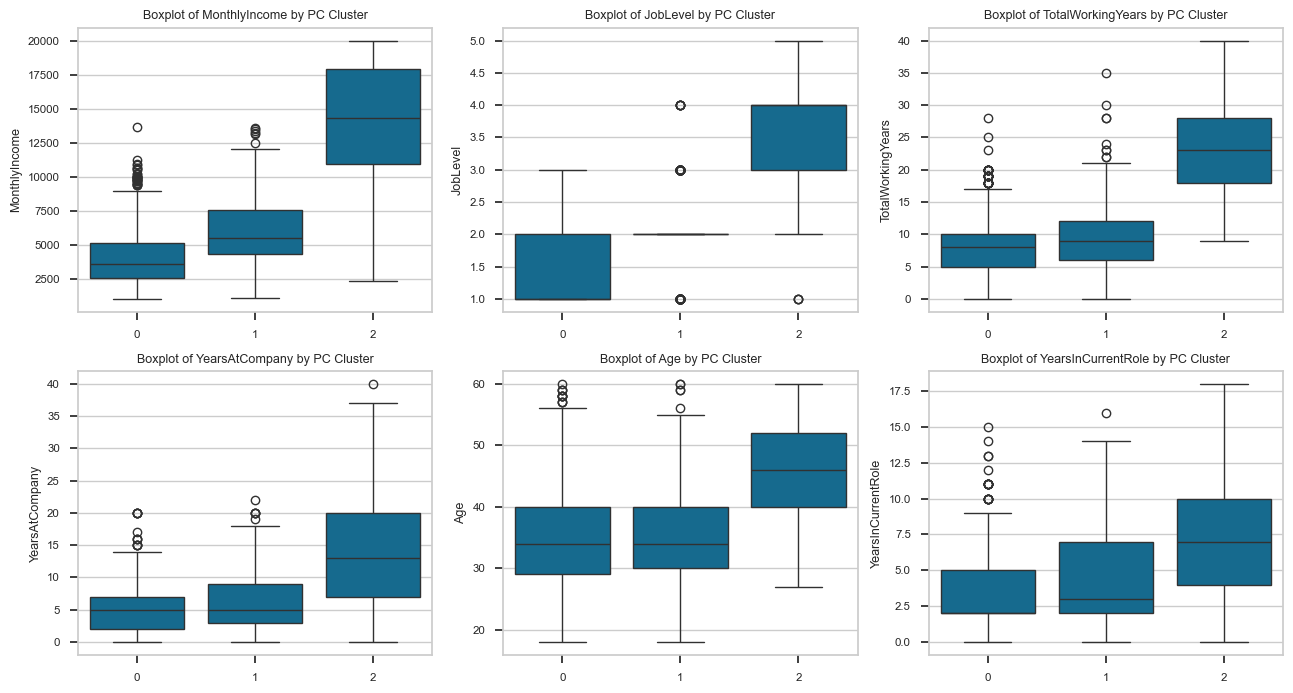

In [28]:
top_feats_pc = eta_pc.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes_flat = axes.flatten()

for i, feature in enumerate(top_feats_pc):
    sns.boxplot(x='Cluster_PC', y=feature, data=df, ax=axes_flat[i])
    axes_flat[i].set_title('Boxplot of %s by PC Cluster' % feature)
    axes_flat[i].set_xlabel('')

plt.tight_layout()
plt.show()


# 7. K-Prototypes Clustering
 -  refer to this link: https://pypi.org/project/kmodes/
 -  perform kprototype clustering
 -  Note that in kprototypes, you dont need to encode the categorical feature

In [29]:
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import minmax_scale

# k-prototypes takes the raw mixed-type table.
kp_data = df[num_keep + cat_feat].copy()
kp_data[num_keep] = minmax_scale(kp_data[num_keep])

cat_idx = [kp_data.columns.get_loc(c) for c in cat_feat]
print("Categorical column indices:", cat_idx)
print("Numerical columns: %d | Categorical columns: %d" % (len(num_keep), len(cat_feat)))


Categorical column indices: [23, 24, 25, 26, 27, 28, 29]
Numerical columns: 23 | Categorical columns: 7


k = 2   cost = 2854.65
k = 3   cost = 2658.12
k = 4   cost = 2548.95
k = 5   cost = 2467.24
k = 6   cost = 2415.49
k = 7   cost = 2376.83
k = 8   cost = 2344.94

Automated elbow on the cost curve -> k = 4


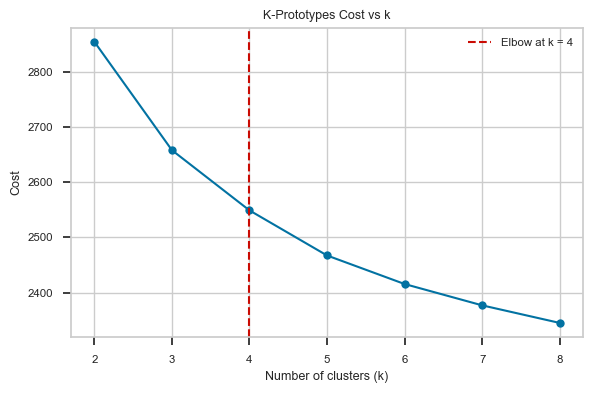

In [30]:
# k-prototypes has no silhouette/WCSS, so k comes from the cost curve.
costs = []
k_range = list(range(2, 9))
for k in k_range:
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=10, random_state=SEED, n_jobs=1)
    kp.fit_predict(kp_data.values, categorical=cat_idx)
    costs.append(kp.cost_)
    print("k = %d   cost = %.2f" % (k, kp.cost_))

elbow_idx = find_elbow_point(costs)
print("\nAutomated elbow on the cost curve -> k =", k_range[elbow_idx])

plt.figure(figsize=(6, 4))
plt.plot(k_range, costs, marker='o')
plt.axvline(x=k_range[elbow_idx], color='r', linestyle='--', label='Elbow at k = %d' % k_range[elbow_idx])
plt.title('K-Prototypes Cost vs k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
OPTIMAL_K_KP = k_range[elbow_idx]

kproto = KPrototypes(n_clusters=OPTIMAL_K_KP, init="Huang", n_init=10, random_state=SEED, n_jobs=1)
labels_kp = kproto.fit_predict(kp_data.values, categorical=cat_idx)

print("K-Prototypes with k = %d" % OPTIMAL_K_KP)
print("Cost  : %.2f" % kproto.cost_)
print("Gamma : %.4f   <- weight of one categorical mismatch relative to one unit of numerical distance"
      % kproto.gamma)


centroids = kproto.cluster_centroids_
cent_num = pd.DataFrame(centroids[:, :len(num_keep)].astype(float), columns=num_keep)
cent_cat = pd.DataFrame(centroids[:, len(num_keep):], columns=cat_feat)

print("\nNumerical centroids (min-max scale, 0 = minimum, 1 = maximum):")
display(np.round(cent_num[['Age', 'JobLevel', 'MonthlyIncome', 'TotalWorkingYears',
                           'JobSatisfaction', 'PerformanceRating', 'PercentSalaryHike']].T, 3))

print("\nCategorical centroids (the mode of each category in each cluster):")
display(cent_cat.T)


K-Prototypes with k = 4
Cost  : 2548.95
Gamma : 0.1324   <- weight of one categorical mismatch relative to one unit of numerical distance

Numerical centroids (min-max scale, 0 = minimum, 1 = maximum):


,0,1,2,3
Age,0.404,0.435,0.394,0.683
JobLevel,0.166,0.223,0.167,0.738
MonthlyIncome,0.194,0.251,0.198,0.732
TotalWorkingYears,0.210,0.264,0.218,0.599
JobSatisfaction,0.835,0.579,0.158,0.566
PerformanceRating,0.000,1.000,0.000,0.043
PercentSalaryHike,0.223,0.774,0.212,0.218



Categorical centroids (the mode of each category in each cluster):


,0,1,2,3
BusinessTravel,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely
Department,Research & Development,Research & Development,Research & Development,Research & Development
EducationField,Life Sciences,Life Sciences,Life Sciences,Life Sciences
Gender,Male,Male,Male,Male
JobRole,Research Scientist,Research Scientist,Sales Executive,Manager
MaritalStatus,Married,Married,Married,Married
OverTime,No,No,No,No


In [32]:
df['Cluster_KP'] = labels_kp

profile_kp = df.groupby('Cluster_KP').agg('mean', numeric_only=True)
profile_kp['Count'] = df.groupby('Cluster_KP')['Cluster_KP'].count()
profile_kp['Attrition_Rate'] = df.groupby('Cluster_KP')[TARGET].apply(lambda s: (s == 'Yes').mean())
profile_kp['Attrition_Count'] = df.groupby('Cluster_KP')[TARGET].apply(lambda s: (s == 'Yes').sum())

display(np.round(profile_kp[interesting].T, 2))

eta_kp = eta_squared(df[num_keep], labels_kp)
print("Top discriminating numerical features (eta-squared):")
print(eta_kp.head(8).round(4).to_string())

print()
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus']:
    print("-- %s (%% within cluster) --" % col)
    display(pd.crosstab(df['Cluster_KP'], df[col], normalize='index').mul(100).round(1))


Cluster_KP,0,1,2,3
Age,34.98,36.26,34.55,46.67
JobLevel,1.66,1.89,1.67,3.95
MonthlyIncome,4693.27,5768.48,4765.37,14906.27
TotalWorkingYears,8.40,10.54,8.70,23.95
YearsAtCompany,5.43,6.53,5.41,14.34
YearsInCurrentRole,3.56,4.31,3.56,7.07
YearsSinceLastPromotion,1.53,2.11,1.55,5.09
YearsWithCurrManager,3.43,4.10,3.64,6.82
StockOptionLevel,0.79,0.80,0.80,0.79
JobSatisfaction,3.51,2.74,1.47,2.70


Top discriminating numerical features (eta-squared):
PerformanceRating    0.9499
MonthlyIncome        0.6127
PercentSalaryHike    0.5664
JobLevel             0.5599
JobSatisfaction      0.5556
TotalWorkingYears    0.5133
YearsAtCompany       0.2764
Age                  0.2202

-- Department (% within cluster) --


Department,Human Resources,Research & Development,Sales
Cluster_KP,,,
0,3.5,65.2,31.3
1,3.7,70.4,25.9
2,5.4,62.0,32.6
3,5.1,66.8,28.1


-- JobRole (% within cluster) --


JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
Cluster_KP,,,,,,,,,
0,8.9,3.5,21.2,0.2,9.0,1.3,24.8,24.5,6.6
1,9.3,3.2,19.4,5.6,12.5,2.8,22.7,19.0,5.6
2,8.3,5.4,20.9,0.0,9.6,1.0,22.2,25.1,7.5
3,9.8,0.9,0.9,37.9,10.2,26.4,0.0,14.0,0.0


-- OverTime (% within cluster) --


OverTime,No,Yes
Cluster_KP,,
0,69.6,30.4
1,70.8,29.2
2,74.9,25.1
3,72.8,27.2


-- MaritalStatus (% within cluster) --


MaritalStatus,Divorced,Married,Single
Cluster_KP,,,
0,21.4,44.3,34.3
1,20.4,46.8,32.9
2,23.0,44.4,32.6
3,25.1,51.1,23.8


In [33]:
from sklearn.metrics import adjusted_rand_score

print("%-22s %-28s %-12s %s" % ("Method", "Attrition rate per cluster", "Spread", "Cluster sizes"))
for name, lab in [("KMeans (44 features)", labels_kmeans),
                  ("KMeans on %d PCs" % N_PC, labels_pc),
                  ("K-Prototypes", labels_kp)]:
    rate = pd.Series(y_attrition).groupby(lab).mean()
    size = pd.Series(lab).value_counts().sort_index()
    print("%-22s %-28s %-12.3f %s" % (name, np.round(rate.values, 3), rate.max() - rate.min(), size.values))

print("\nBaseline attrition rate: %.3f" % y_attrition.mean())

print("\nAdjusted Rand Index between solutions:")
print("  KMeans (44) vs KMeans on PCs : %.4f" % adjusted_rand_score(labels_kmeans, labels_pc))
print("  KMeans (44) vs K-Prototypes  : %.4f" % adjusted_rand_score(labels_kmeans, labels_kp))
print("  KMeans on PCs vs K-Prototypes: %.4f" % adjusted_rand_score(labels_pc, labels_kp))


Method                 Attrition rate per cluster   Spread       Cluster sizes
KMeans (44 features)   [0.165 0.172 0.056 0.398]    0.341        [819 319 249  83]
KMeans on 8 PCs        [0.169 0.219 0.058]          0.161        [795 398 277]
K-Prototypes           [0.16  0.171 0.204 0.085]    0.119        [632 216 387 235]

Baseline attrition rate: 0.161

Adjusted Rand Index between solutions:
  KMeans (44) vs KMeans on PCs : 0.8880
  KMeans (44) vs K-Prototypes  : 0.1826
  KMeans on PCs vs K-Prototypes: 0.1953


## 7a. K-prototype results analysis

**What are your thoughts and observations about kprototype vs kmeans?**

K-prototypes is the weaker method here.

1. The categorical features did nothing - all four clusters take the same mode for BusinessTravel, Department, EducationField, Gender, MaritalStatus and OverTime, and only JobRole differs.
2. Gamma came out at 0.1324, so one categorical mismatch costs 0.13 while one scaled numerical feature can differ by 1.0. With 23 numerical columns against 7 categorical, the numerical side dominates roughly 25 to 1.
3. Min-max scaling creates an artefact. PerformanceRating has the highest eta2 (0.95) only because it takes the values 3 and 4, so after scaling it is a binary switch worth a full unit of distance - as much as the whole \$1,009-\$19,999 range of MonthlyIncome. JobSatisfaction (0.56) behaves the same way.
4. There is no internal validation index, only the cost, which falls monotonically with k, so the choice of k is a judgement call.

The one advantage is that no encoding step is needed, and the centroids read as business terms.

**Are the results more interpretable?**

No, less. Clusters 0/2 and cluster 1 are separated by "PerformanceRating 3 vs 4", and 84.6% of staff are rated 3, so it is not a real segment. The attrition spread is also the smallest of the three methods (0.119 against 0.341 and 0.161).

| Cluster | Size | Profile | Attrition |
|---|---|---|---|
| 0 | 632 | Junior, JobLevel 1.7, \$4,693/month, Rating 3, Satisfaction 3.5 | 16.0% |
| 1 | 216 | Rating 4, SalaryHike 21.8%, JobLevel 1.9 | 17.1% |
| 2 | 387 | Junior, JobLevel 1.7, \$4,765/month, Rating 3, Satisfaction 1.5 | 20.4% |
| 3 | 235 | Senior, Age 46.7, JobLevel 4.0, \$14,906/month, 24 years experience | 8.5% |

Only cluster 3 is a real business segment, and it matches the senior group from the PC-based KMeans.


## Conclusion:  Write your thoughts and analysis about the above 3 clustering approaches.

**Analyze the cluster output from the above methods**

| | KMeans (44 features) | KMeans on 8 PCs | K-Prototypes |
|---|---|---|---|
| k | 4 | 3 | 4 |
| Silhouette | 0.1046 | 0.2236 | not available |
| Davies-Bouldin | 2.409 | 1.607 | not available |
| Attrition spread | 0.341 | 0.161 | 0.119 |
| The clusters are | Job families | Career stage x line of business | Senior vs the rest, plus a rating artefact |

KMeans on the 44 features gives the job families again (99.7% Sales Executive, 100% Sales Representative, 40% Manager). The 0.341 spread comes from one 83-person cluster and `groupby('JobRole')` gives the same answer, so it was the weakest solution - 21 of the 44 dimensions are one-hot dummies.

KMeans on the 8 PCs gives three balanced clusters on career stage and line of business, with roughly double the technical quality.

K-Prototypes is the least interpretable: the categorical centroids are identical across clusters, the split is driven by the min-max artefact around PerformanceRating, and the attrition spread is the smallest.

**Which clustering solution yeilded the most "optimal" way to profile staff attrition?**

KMeans on the 8 principal components.

**Why is it considered an "optimal" solution in your opinion?**

1. All three indices agree on k = 3, unlike the 44-feature solution.
2. Best technical quality - silhouette 0.22 against 0.10, Davies-Bouldin 1.61 against 2.41.
3. The clusters sit on interpretable axes (career stage, job family), not on a dummy or a scaling artefact.
4. It gives a usable risk gradient: 21.9% (sales) > 16.9% (R&D technical) > 5.8% (senior) against a 16.1% baseline.
5. It is stable - 5, 8, 10 or 19 PCs all give the same three-cluster structure.

The caveat is that none of them really answers the business question. Overtime staff leave at 30.5% against 10.4%, but every cluster in every solution has 27%-31% overtime. Clustering groups people by role and seniority, which is not what makes them leave, so the PC-based KMeans is the best of the three for describing the workforce while a supervised model is still the right tool for predicting attrition.


---